--- DataFrame Titanic Dimuat ---
        survived  pclass                                               name  \
0  tidak selamat       3                            Braund, Mr. Owen Harris   
1        selamat       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2        selamat       3                             Heikkinen, Miss. Laina   
3        selamat       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4  tidak selamat       3                           Allen, Mr. William Henry   

      sex   age     fare  sibsp  parch  
0    male  22.0   7.2500      1      0  
1  female  38.0  71.2833      1      0  
2  female  26.0   7.9250      0      0  
3  female  35.0  53.1000      1      0  
4    male  35.0   8.0500      0      0  


### 1. Rata-rata (Mean) Kolom Terpilih ###
age       29.70
fare      34.69
pclass     2.24
dtype: float64
Tingkat Kelangsungan Hidup: 40.62%

--------------------------------------------------

### 2. Nilai Maksimum (Max) dan Minimum (Min) ###


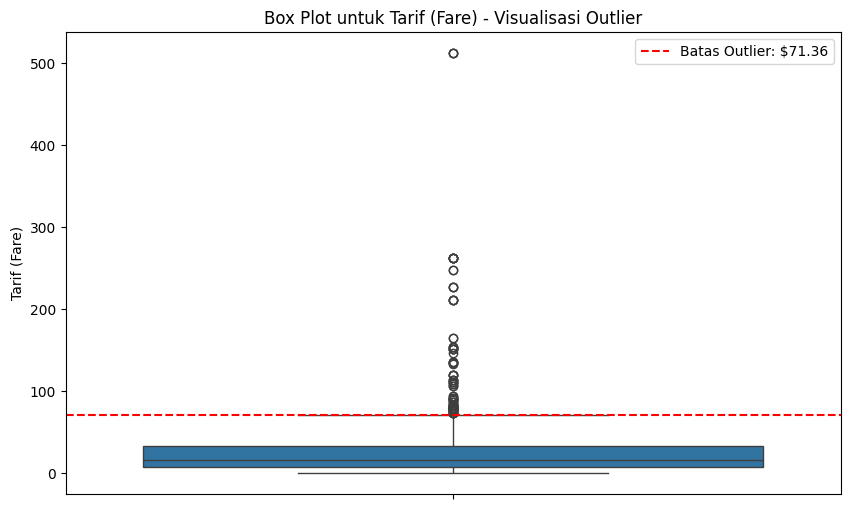

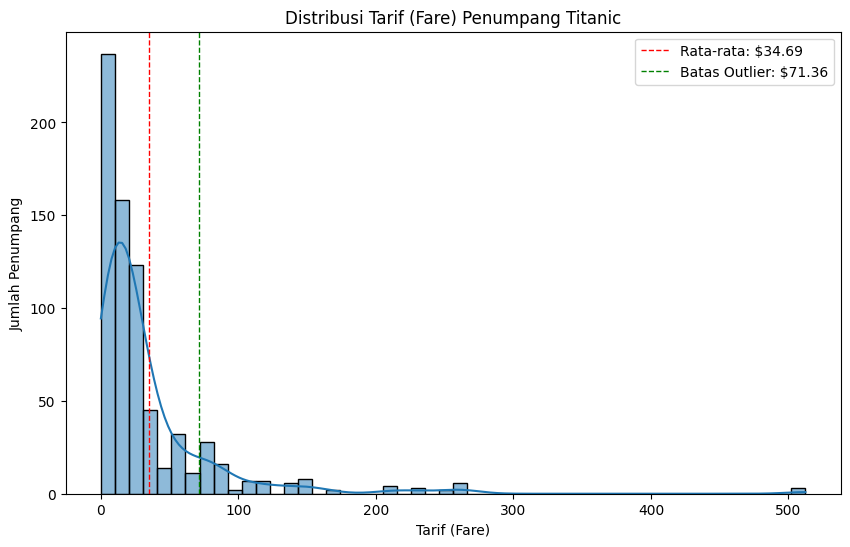

### VISUALISASI TAMBAHAN ###


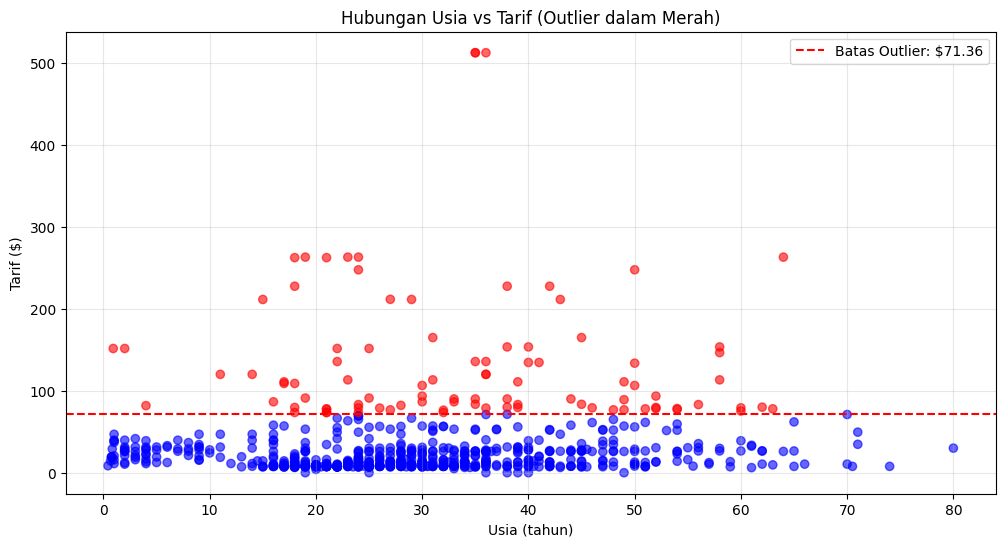

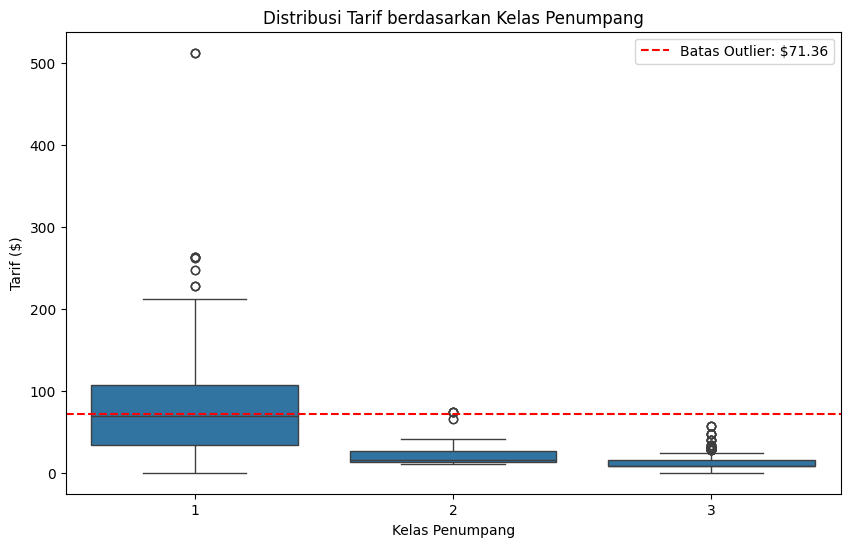

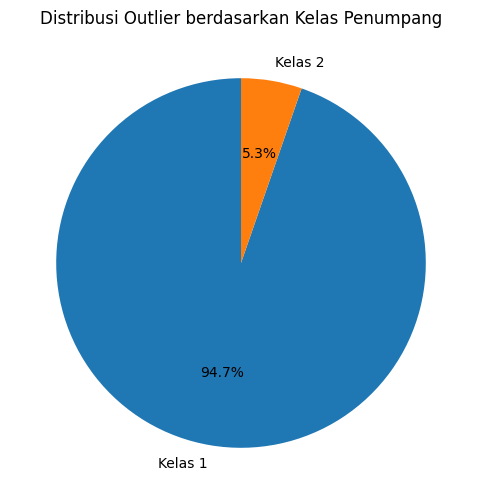


ANALISIS OUTLIER SELESAI


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Muat Dataset
df = pd.read_csv('titanic.csv')
df['survived'] = df['survived'].map({1: 'selamat', 0: 'tidak selamat'})

print("--- DataFrame Titanic Dimuat ---")
print(df.head())
print("\n" + "="*50 + "\n")

## Analisis Statistik Deskriptif

# 2. Identifikasi Rata-rata (Mean)
print("### 1. Rata-rata (Mean) Kolom Terpilih ###")
mean_values = df[['age', 'fare', 'pclass']].mean().round(2)
print(mean_values)

# hitung persentase survived
survived_counts = df['survived'].value_counts()
total_passengers = len(df)
selamat_percentage = (survived_counts.get('selamat', 0) / total_passengers) * 100
print(f"Tingkat Kelangsungan Hidup: {selamat_percentage:.2f}%")
print("\n" + "-"*50 + "\n")

# 3. Identifikasi Nilai Maksimum dan Minimum untuk Usia dan Tarif
print("### 2. Nilai Maksimum (Max) dan Minimum (Min) ###")
max_age = df['age'].max()
min_age = df['age'].min()
max_fare = df['fare'].max()
min_fare = df['fare'].min()

print(f"Usia Maksimum: {max_age} tahun")
print(f"Usia Minimum: {min_age} tahun")
print(f"Tarif Maksimum: ${max_fare:.2f}")
print(f"Tarif Minimum: ${min_fare:.2f}")
print("\n" + "="*50 + "\n")

## Identifikasi dan Visualisasi Outlier Fare

# 4. Identifikasi Outlier Fare (Metode IQR)
print("### 3. Identifikasi Outlier (Data Pencilan) Tarif (Fare) ###")

Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers_fare = df[(df['fare'] > upper_bound) | (df['fare'] < lower_bound)]

print(f"Q1 (25th percentile): ${Q1:.2f}")
print(f"Q3 (75th percentile): ${Q3:.2f}")
print(f"IQR: ${IQR:.2f}")
print(f"Batas Atas Outlier: ${upper_bound:.2f}")
print(f"Batas Bawah Outlier: ${lower_bound:.2f}")
print(f"\nTotal Outlier Fare Ditemukan: {len(outliers_fare)} penumpang")
print("\n" + "-"*50 + "\n")

# TAMPILKAN NILAI OUTLIER SECARA DETAIL
print("### DETAIL NILAI OUTLIER ###")
print("\n--- Statistik Outlier ---")
print(f"Jumlah total outlier: {len(outliers_fare)}")

# Hitung persentase
outlier_percentage = (len(outliers_fare) / len(df)) * 100
print(f"Persentase outlier: {outlier_percentage:.2f}%")

print(f"Tarif minimum outlier: ${outliers_fare['fare'].min():.2f}")
print(f"Tarif maksimum outlier: ${outliers_fare['fare'].max():.2f}")
print(f"Rata-rata tarif outlier: ${outliers_fare['fare'].mean():.2f}")
print(f"Median tarif outlier: ${outliers_fare['fare'].median():.2f}")

print("\n--- Distribusi Kelas pada Outlier ---")
outlier_class_dist = outliers_fare['pclass'].value_counts().sort_index()
for pclass, count in outlier_class_dist.items():
    percentage = (count / len(outliers_fare)) * 100
    print(f"Kelas {pclass}: {count} penumpang ({percentage:.1f}%)")

print("\n--- Tingkat Survival Outlier ---")
outlier_survival = outliers_fare['survived'].value_counts()
selamat_count = outlier_survival.get('selamat', 0)
tidak_selamat_count = outlier_survival.get('tidak selamat', 0)
survival_rate = (selamat_count / len(outliers_fare)) * 100
print(f"Selamat: {selamat_count} penumpang")
print(f"Tidak selamat: {tidak_selamat_count} penumpang")
print(f"Tingkat survival outlier: {survival_rate:.2f}%")

print("\n--- Distribusi Gender pada Outlier ---")
outlier_gender_dist = outliers_fare['sex'].value_counts()
for gender, count in outlier_gender_dist.items():
    percentage = (count / len(outliers_fare)) * 100
    print(f"{gender}: {count} penumpang ({percentage:.1f}%)")

print("\n--- 10 OUTLIER TARIF TERTINGGI ---")
top_10_outliers = outliers_fare.nlargest(10, 'fare')[['name', 'pclass', 'age', 'fare', 'survived', 'sex']]
print(top_10_outliers.to_string(index=False))

print("\n--- 5 OUTLIER TARIF TERENDAH ---")
bottom_5_outliers = outliers_fare.nsmallest(5, 'fare')[['name', 'pclass', 'age', 'fare', 'survived', 'sex']]
print(bottom_5_outliers.to_string(index=False))

print("\n--- OUTLIER DENGAN TARIF UNIK ---")
unique_fare_outliers = outliers_fare['fare'].unique()
print(f"Jumlah nilai tarif unik pada outlier: {len(unique_fare_outliers)}")
print("10 nilai tarif unik tertinggi:")
print(np.sort(unique_fare_outliers)[-10:].round(2))

print("\n--- PERBANDINGAN OUTLIER vs NON-OUTLIER ---")
non_outliers = df[~df.index.isin(outliers_fare.index)]
print(f"Rata-rata tarif non-outlier: ${non_outliers['fare'].mean():.2f}")

# Hitung survival rate non-outlier
non_outlier_survival_counts = non_outliers['survived'].value_counts()
non_outlier_selamat_count = non_outlier_survival_counts.get('selamat', 0)
non_outlier_survival_rate = (non_outlier_selamat_count / len(non_outliers)) * 100
print(f"Tingkat survival non-outlier: {non_outlier_survival_rate:.2f}%")

print(f"Rata-rata usia non-outlier: {non_outliers['age'].mean():.2f} tahun")

print("\n" + "="*50 + "\n")

# 5. Visualisasi Outlier Fare (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['fare'])
plt.title('Box Plot untuk Tarif (Fare) - Visualisasi Outlier')
plt.ylabel('Tarif (Fare)')
plt.axhline(y=upper_bound, color='red', linestyle='--', label=f'Batas Outlier: ${upper_bound:.2f}')
plt.legend()
plt.show()

# 6. Visualisasi Sebaran Data (Histogram) untuk melihat distribusi
plt.figure(figsize=(10, 6))
sns.histplot(df['fare'], bins=50, kde=True)
plt.axvline(df['fare'].mean(), color='red', linestyle='dashed', linewidth=1, label=f'Rata-rata: ${df["fare"].mean():.2f}')
plt.axvline(upper_bound, color='green', linestyle='dashed', linewidth=1, label=f'Batas Outlier: ${upper_bound:.2f}')
plt.title('Distribusi Tarif (Fare) Penumpang Titanic')
plt.xlabel('Tarif (Fare)')
plt.ylabel('Jumlah Penumpang')
plt.legend()
plt.show()

# 7. VISUALISASI TAMBAHAN UNTUK OUTLIER
print("### VISUALISASI TAMBAHAN ###")

# Scatter plot usia vs tarif dengan highlight outlier
plt.figure(figsize=(12, 6))
colors = ['red' if fare > upper_bound else 'blue' for fare in df['fare']]
plt.scatter(df['age'], df['fare'], c=colors, alpha=0.6)
plt.xlabel('Usia (tahun)')
plt.ylabel('Tarif ($)')
plt.title('Hubungan Usia vs Tarif (Outlier dalam Merah)')
plt.axhline(y=upper_bound, color='red', linestyle='--', label=f'Batas Outlier: ${upper_bound:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Box plot tarif berdasarkan kelas
plt.figure(figsize=(10, 6))
sns.boxplot(x='pclass', y='fare', data=df)
plt.axhline(y=upper_bound, color='red', linestyle='--', label=f'Batas Outlier: ${upper_bound:.2f}')
plt.title('Distribusi Tarif berdasarkan Kelas Penumpang')
plt.xlabel('Kelas Penumpang')
plt.ylabel('Tarif ($)')
plt.legend()
plt.show()

# Pie chart distribusi outlier berdasarkan kelas
plt.figure(figsize=(8, 6))
outlier_class_counts = outliers_fare['pclass'].value_counts()
plt.pie(outlier_class_counts.values, labels=[f'Kelas {cls}' for cls in outlier_class_counts.index], 
        autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Outlier berdasarkan Kelas Penumpang')
plt.show()

print("\n" + "="*50)
print("ANALISIS OUTLIER SELESAI")
print("="*50)